In [1]:
import math
import torch
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import datasets
import torchvision.transforms as transforms

import matplotlib.pyplot as plt

In [2]:
data = datasets.MNIST(
    root='data',
    download=True,
    transform=transforms.Compose([
        transforms.Resize((16, 16)),
        transforms.ToTensor()
    ])
)

In [3]:
# Filtrar los índices de las muestras que pertenecen a la clase del 1
indices_clase_1 = [i for i, (img, label) in enumerate(data) if label == 1]

In [4]:
# Crear un dataset con solo esos ejemplos (usando Subset)
dataset_clase_1 = Subset(data, indices_clase_1)

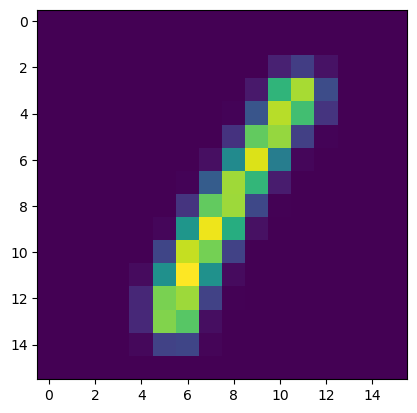

In [12]:
plt.imshow(dataset_clase_1.__getitem__(0)[0].permute(1, 2, 0))

In [5]:
# Crear el DataLoader para el dataset filtrado
dataloader = DataLoader(dataset_clase_1, batch_size=120, shuffle=True)

In [6]:
from torch import nn, optim
from unet_ddpm2d import Unet
from ddpm import Diffusion_Scheme
from tqdm import tqdm
import matplotlib.pyplot as plt

In [15]:
epochs = 25
image_size = data.__getitem__(0)[0].shape[1]
device = "mps"
lr = 3e-7
num_channels = 1

In [8]:
model = Unet(dim=image_size, channels=num_channels).to(device)
optimizer = optim.AdamW(model.parameters(), lr)
mse = nn.MSELoss()
diffusion = Diffusion_Scheme(image_size = image_size, device = device)

100%|██████████| 57/57 [00:12<00:00,  4.64it/s, MSE=0.0201]


Sampleando 1 nuevas imágenes a partir del modelo entrenado...


999it [00:32, 31.01it/s]


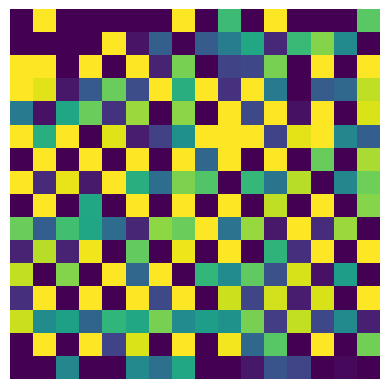

100%|██████████| 57/57 [00:12<00:00,  4.65it/s, MSE=0.0132]


Sampleando 1 nuevas imágenes a partir del modelo entrenado...


999it [00:32, 31.16it/s]


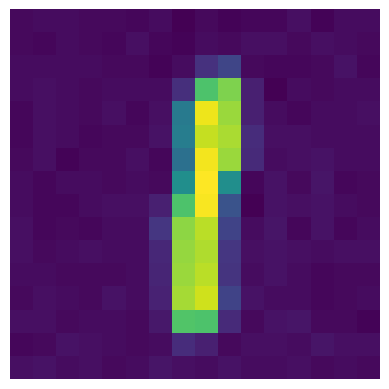

100%|██████████| 57/57 [00:12<00:00,  4.65it/s, MSE=0.0246]


Sampleando 1 nuevas imágenes a partir del modelo entrenado...


999it [00:31, 31.29it/s]


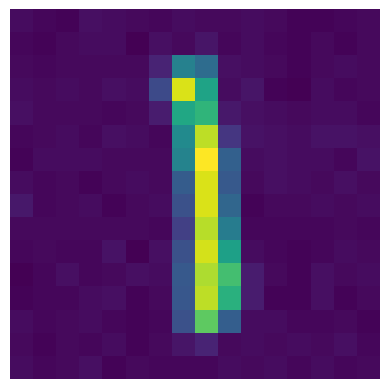

100%|██████████| 57/57 [00:12<00:00,  4.57it/s, MSE=0.0208]


Sampleando 1 nuevas imágenes a partir del modelo entrenado...


999it [00:32, 30.99it/s]


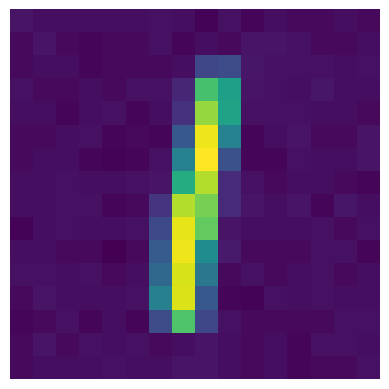

 19%|█▉        | 11/57 [00:02<00:10,  4.20it/s, MSE=0.016] 


KeyboardInterrupt: 

In [17]:
for epoch in range(epochs):
    prog_bar = tqdm(dataloader)
    model.train()
    for count, (images, _) in enumerate(prog_bar):

        images = images.to(device)
        t = diffusion.sample_timesteps(images.shape[0]).to(device)
        x_t, noise = diffusion.noise_images(images, t)
        predicted_noise = model(x_t, t)
        loss = mse(noise, predicted_noise)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        prog_bar.set_postfix(MSE = loss.item())
    
    if (epoch + 1) % 5 == 0:
        sampled_image = diffusion.sampling(model, num_channels=num_channels, n = 1)
        plt.imshow(sampled_image[0].permute(1, 2, 0).to('cpu').numpy())
        plt.axis('off')
        plt.show()